# Test: gf_reduce() and gf_square_reduce()

Tests the SS Model visualization functions.

- `gf_reduce()` — vertical lines from grand mean to complex model predictions
- `gf_square_reduce()` — same distances drawn as squares

Together with `gf_resid()` / `gf_square_resid()`, these let students see the
full SS decomposition: **SS Total = SS Model + SS Error**.

In [30]:
#pak::pak("coursekata/coursekata-r")
library(coursekata)
source("../gf_reduce.R")

# Models used throughout
m_empty   <- lm(Thumb ~ NULL,   data = Fingers)
m_complex <- lm(Thumb ~ Height, data = Fingers)

## Basic usage

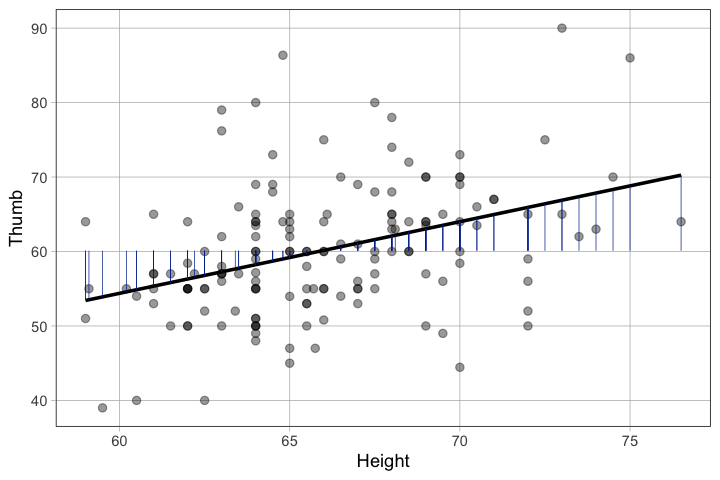

In [31]:
# Test 1: gf_reduce — lines from grand mean to model predictions
# Lines should be vertical, running from the horizontal grand-mean level
# up (or down) to each point's fitted value on the regression line
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_complex) %>%
  gf_reduce(m_complex)

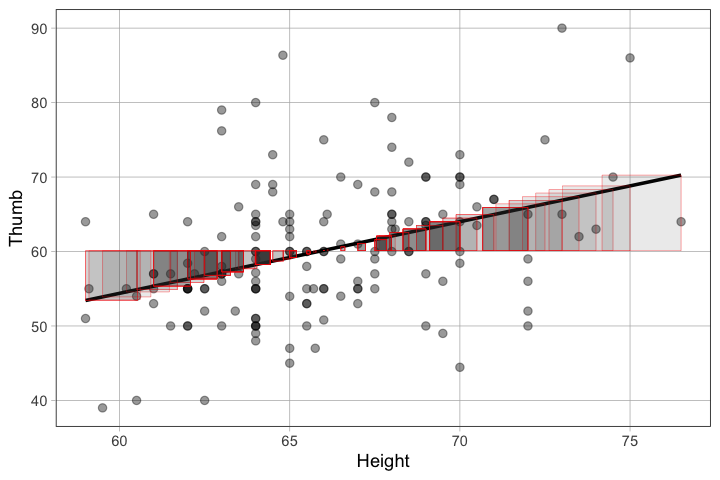

In [32]:
# Test 2: gf_square_reduce — same distances as squares
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_complex) %>%
  gf_square_reduce(m_complex, color="red", linewidth = .1)

## Jitter alignment

The lines and squares must anchor to the jittered x positions, not the original
data x values. Run each cell a few times — the lines should follow the dots.

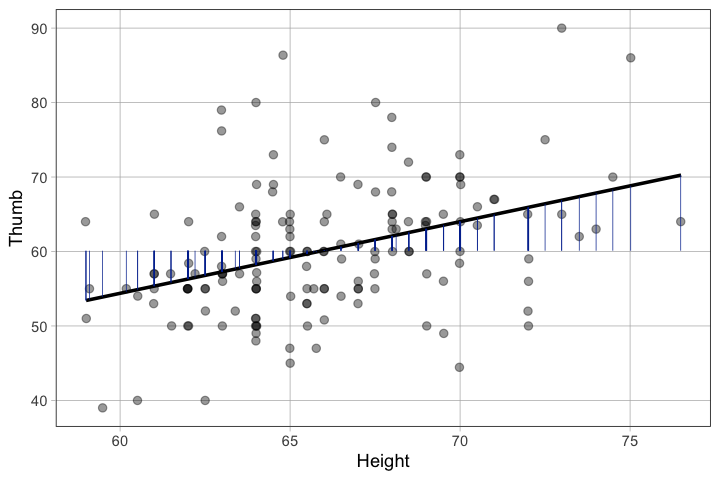

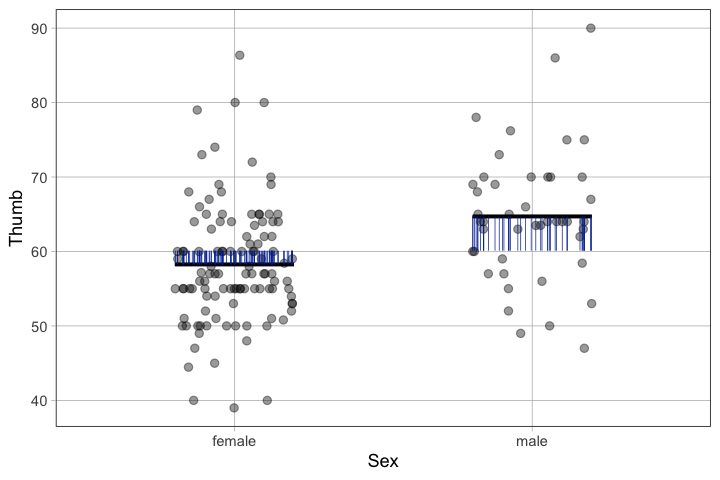

In [33]:
# Test 3: gf_reduce with jitter — lines should follow the jittered dots
gf_jitter(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_complex) %>%
  gf_reduce(m_complex)

catx_model <- lm(Thumb ~ Sex, data = Fingers)
# Test 3b: gf_reduce with jitter (categorical x) — lines should follow the jittered dots
gf_jitter(Thumb ~ Sex, data = Fingers, width = .2, alpha = 0.4) %>%
  gf_model(catx_model) %>%
  gf_reduce(catx_model)



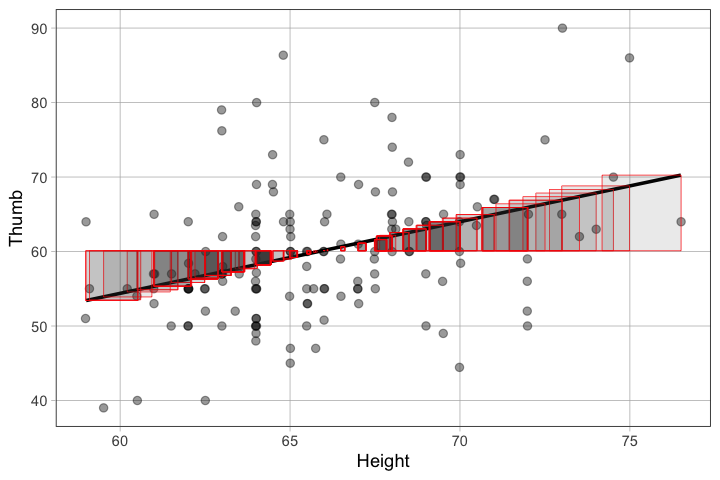

In [34]:
# Test 4: gf_square_reduce with jitter
gf_jitter(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_complex) %>%
  gf_square_reduce(m_complex, color = "red", linewidth = .2)

## With and without gf_model()

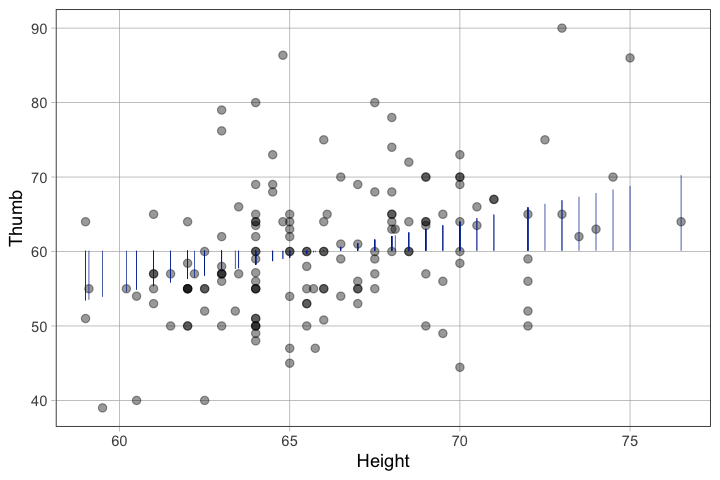

In [35]:
# Test 5: gf_reduce without gf_model() — should still work
# Lines appear without the regression line overlay
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_reduce(m_complex)

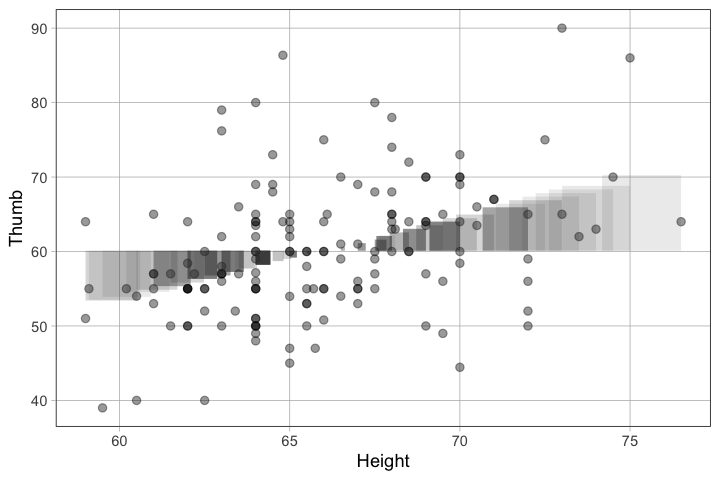

In [36]:
# Test 6: gf_square_reduce without gf_model()
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_square_reduce(m_complex)

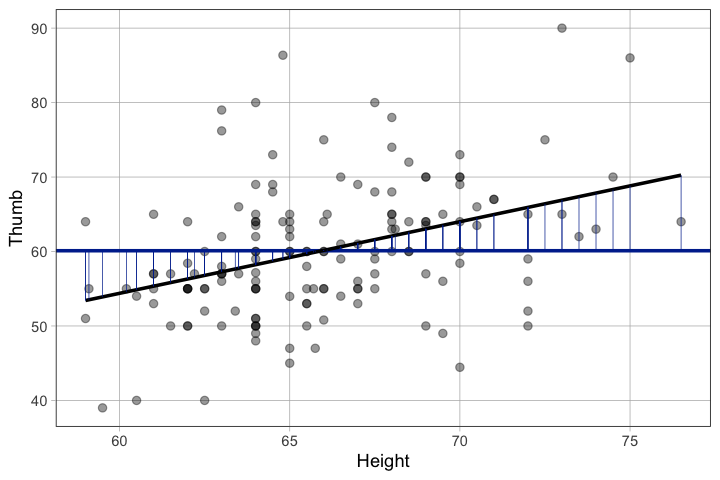

In [37]:
# Test 7: both gf_model(empty) and gf_model(complex) on the same plot
# Should show the grand mean line, the regression line, and the reduce lines
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_empty) %>%
  gf_model(m_complex) %>%
  gf_reduce(m_complex)

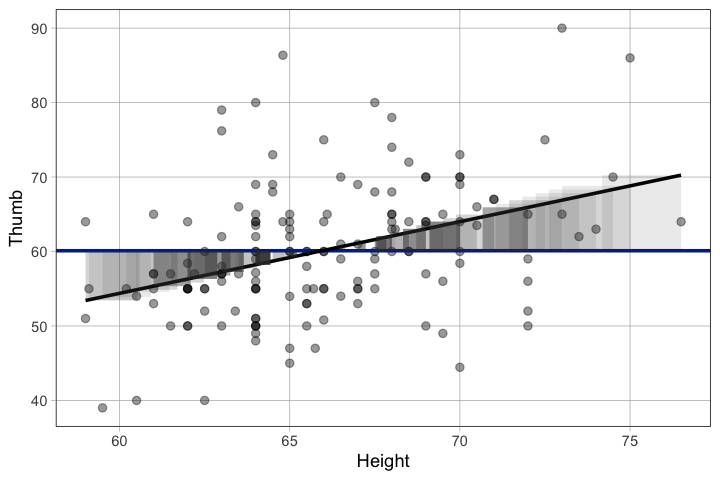

In [38]:
# Test 8: both models + squares
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_empty) %>%
  gf_model(m_complex) %>%
  gf_square_reduce(m_complex)

## Full SS decomposition

All three square types on the same plot. SS Total = SS Model + SS Error.
The blue squares (SS Total) should visually equal the red (SS Error) + green (SS Model).

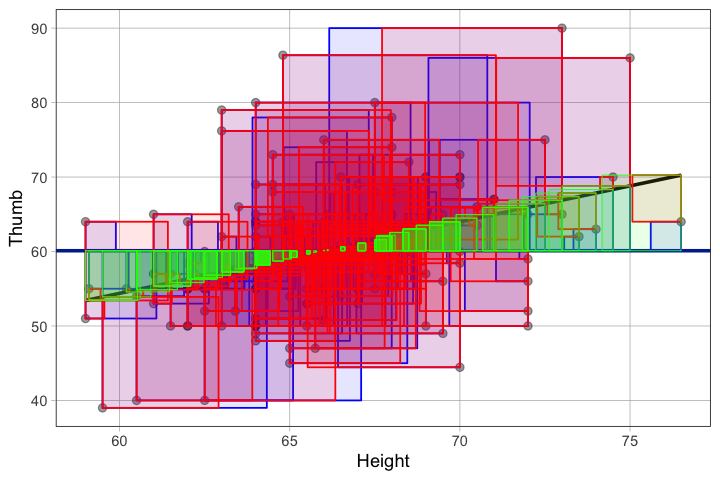

In [39]:
# Test 9: full decomposition — SS Total, SS Error, SS Model
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_empty) %>%
  gf_model(m_complex) %>%
  gf_square_resid(m_empty,    fill = "blue",  color = "blue", alpha = .1)  %>%   # SS Total
  gf_square_resid(m_complex,  fill = "red",   color = "red", alpha = .1)   %>%   # SS Error
  gf_square_reduce(m_complex, fill = "green", color = "green", alpha = .1)       # SS Model

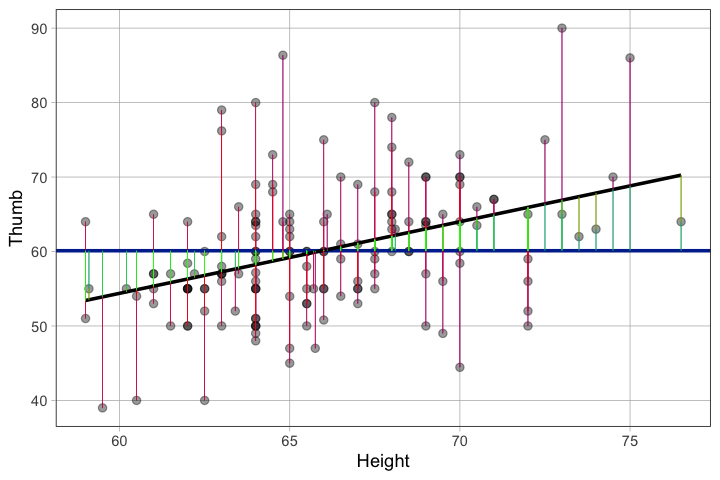

In [40]:
# Test 10: same decomposition with lines instead of squares
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_empty) %>%
  gf_model(m_complex) %>%
  gf_resid(m_empty,   color = "blue")   %>%   # SS Total
  gf_resid(m_complex, color = "red")    %>%   # SS Error
  gf_reduce(m_complex, color = "green")       # SS Model

## Few vs many data points

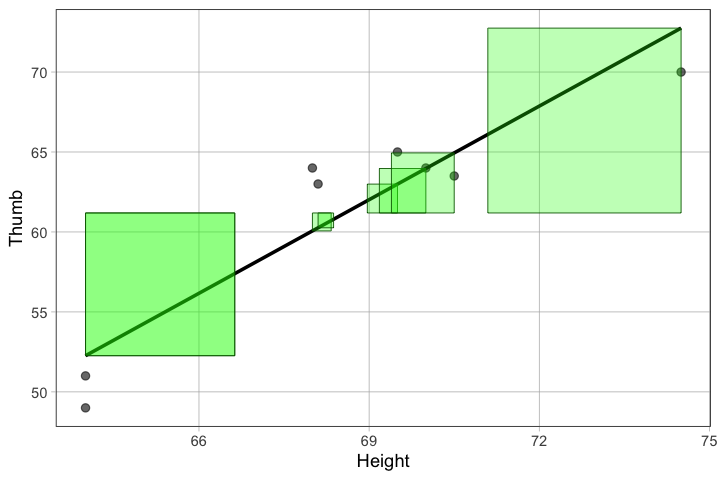

In [41]:
# Test 11: very few points (n=8) — squares should be easy to inspect individually
set.seed(1)
d_small <- Fingers[sample(nrow(Fingers), 8), ]
m_small <- lm(Thumb ~ Height, data = d_small)

gf_point(Thumb ~ Height, data = d_small) %>%
  gf_model(m_small) %>%
  gf_square_reduce(m_small, fill = "green", color = "darkgreen", alpha = 0.3)

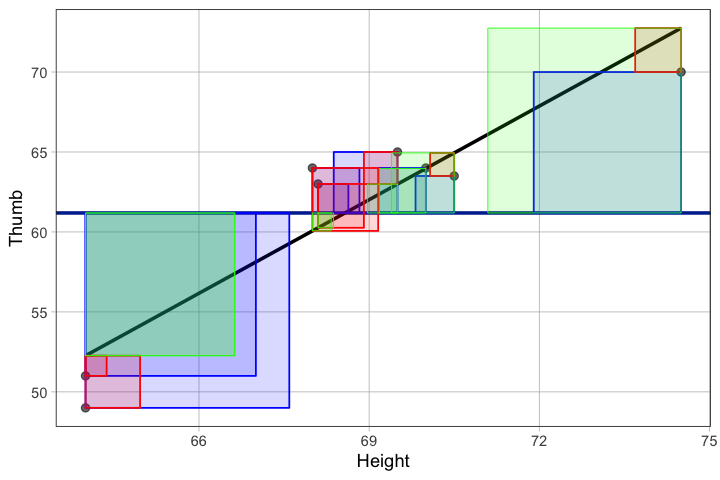

In [42]:
# Test 12: full decomposition with few points — verify areas add up visually
m_small_empty <- lm(Thumb ~ NULL, data = d_small)

gf_point(Thumb ~ Height, data = d_small) %>%
  gf_model(m_small_empty) %>%
  gf_model(m_small) %>%
  gf_square_resid(m_small_empty, fill = "blue",  color = "blue",  alpha = 0.15) %>%
  gf_square_resid(m_small,       fill = "red",   color = "red",   alpha = 0.15) %>%
  gf_square_reduce(m_small,      fill = "green", color = "green", alpha = 0.15)

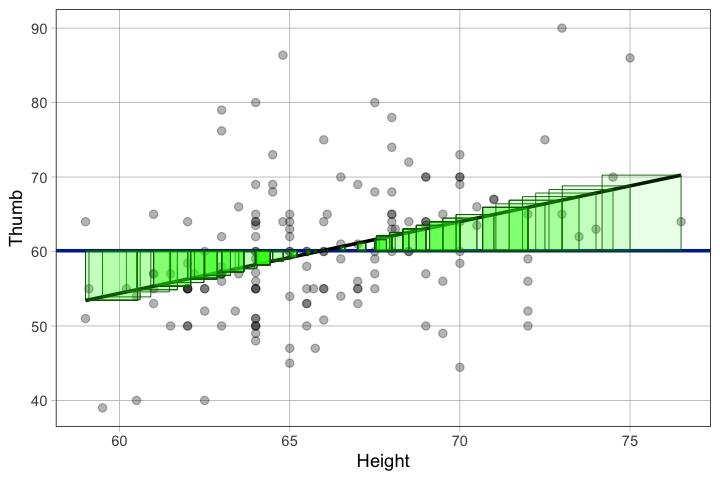

In [43]:
# Test 13: full dataset (n=157) — squares will overlap, check it doesn't error
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.3) %>%
  gf_model(m_empty) %>%
  gf_model(m_complex) %>%
  gf_square_reduce(m_complex, fill = "green", color = "darkgreen", alpha = 0.1)

## Categorical x

In [51]:
set.seed(2)
er_small <- sample(er, 12)

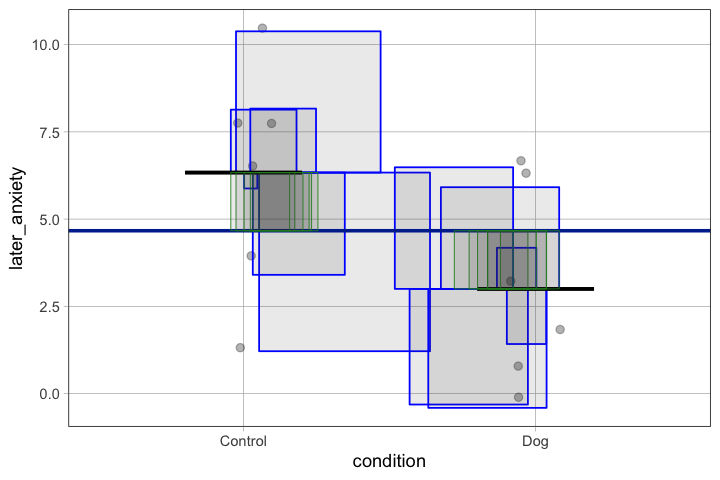

In [57]:
# Test 14: categorical x — reduce lines from grand mean to group means
m_cat_empty   <- lm(later_anxiety ~ NULL,      data = er_small)
m_cat_complex <- lm(later_anxiety ~ condition, data = er_small)

gf_jitter(later_anxiety ~ condition, data = er_small, width = 0.1, alpha = 0.3) %>%
  gf_square_resid(m_cat_complex, color = "blue") %>%
  gf_model(m_cat_empty) %>%
  gf_model(m_cat_complex) %>%
  gf_square_reduce(m_cat_complex, color = "forestgreen") 

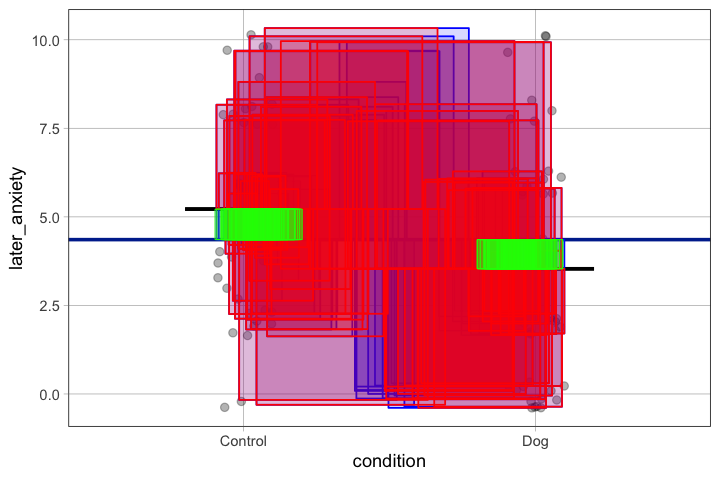

In [45]:
# Test 15: categorical x — full decomposition as squares
gf_jitter(later_anxiety ~ condition, data = er, width = 0.1, alpha = 0.3) %>%
  gf_model(m_cat_empty) %>%
  gf_model(m_cat_complex) %>%
  gf_square_resid(m_cat_empty,    fill = "blue",  color = "blue",  alpha = 0.15) %>%
  gf_square_resid(m_cat_complex,  fill = "red",   color = "red",   alpha = 0.15) %>%
  gf_square_reduce(m_cat_complex, fill = "green", color = "green", alpha = 0.15)

## Aesthetics and edge cases

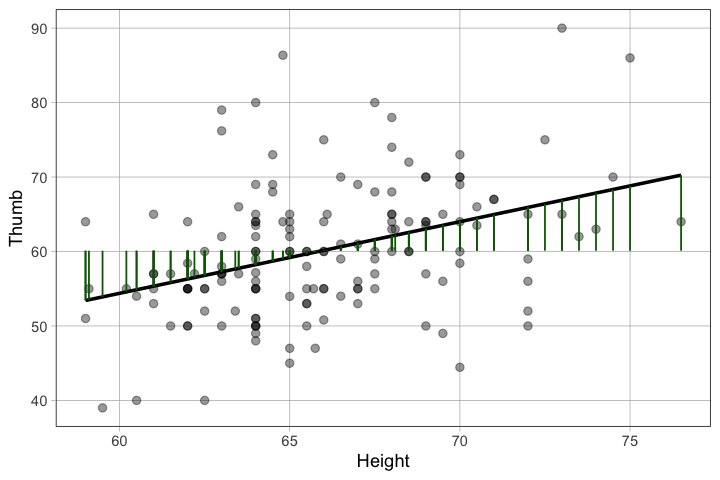

In [46]:
# Test 16: custom fixed color and linewidth for gf_reduce
gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
  gf_model(m_complex) %>%
  gf_reduce(m_complex, color = "darkgreen", linewidth = 0.5)

In [47]:
# Test 17: fill = ~Sex — expected to FAIL or be ignored
# gf_square_reduce builds its own squares_data frame that doesn't carry
# original data columns, so mapped aesthetics like fill = ~Sex won't work.
# This test documents the known limitation.
tryCatch(
  gf_point(Thumb ~ Height, data = Fingers, alpha = 0.4) %>%
    gf_model(m_complex) %>%
    gf_square_reduce(m_complex, fill = ~Sex, alpha = 0.3),
  error   = function(e) cat("Error (expected):", conditionMessage(e), "\n"),
  warning = function(w) cat("Warning (expected):", conditionMessage(w), "\n")
)

ERROR while rich displaying an object: Error in `ggplot2::geom_polygon()`:
! Problem while setting up geom aesthetics.
i Error occurred in the 3rd layer.
Caused by error in `list_sizes()`:
! `x$fill` must be a vector, not a <formula> object.
i Read our FAQ about scalar types (`?vctrs::faq_error_scalar_type`) to learn more.

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 


In [48]:
# Test 18: numerical sanity — SS Model from gf_square_reduce should match supernova
# The sum of squared reductions should equal SS Model from the ANOVA table
ss_model_visual <- sum((fitted(m_complex) - mean(fitted(m_complex)))^2)
ss_model_anova  <- supernova(m_complex)$tbl$SS[1]   # SS Model row

cat("SS Model (visual):", round(ss_model_visual, 4), "\n")
cat("SS Model (anova): ", round(ss_model_anova,  4), "\n")
cat("Match:", isTRUE(all.equal(ss_model_visual, ss_model_anova)), "\n")

SS Model (visual): 1816.862 
SS Model (anova):  1816.862 
Match: TRUE 
